# UAS Penambangan Data
## Higher Education Students Performance Evaluation

**Dataset:** UCI Machine Learning Repository (ID: 856)

**Tujuan:** Melakukan analisis untuk menebak grade mahasiswa berdasarkan semua fitur performa menggunakan teknik Data Mining (Decision Tree).

**Tahapan:**
1. Import & Load Data
2. Exploratory Data Analysis (EDA)
3. Preprocessing (Cek Tipe Data)
4. Modeling (Decision Tree)
5. Evaluasi
6. Kesimpulan

## 1. Import Library & Load Dataset

In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\users\lenovo\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip


  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Semua library berhasil di-import!")

Semua library berhasil di-import!


In [3]:
# Fetch dataset dari UCI ML Repository
dataset = fetch_ucirepo(id=856)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)
print(f"Dataset berhasil dimuat!")
print(f"  Jumlah data  : {df.shape[0]} baris")
print(f"  Jumlah kolom : {df.shape[1]} kolom")
print(f"  Features     : {X.shape[1]}")
print(f"  Target       : OUTPUT Grade")

Dataset berhasil dimuat!
  Jumlah data  : 145 baris
  Jumlah kolom : 32 kolom
  Features     : 31
  Target       : OUTPUT Grade


In [4]:
# Tampilkan 5 data pertama
df.head()

,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID,OUTPUT Grade
0,2,2,3,3,1,2,2,1,1,1,...,1,1,3,2,1,2,1,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,3,2,3,2,2,3,1,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,2,2,1,1,2,2,1,1
3,1,1,1,3,1,2,1,2,1,2,...,1,2,3,2,2,1,3,2,1,1
4,2,2,1,3,2,2,1,3,1,4,...,2,1,2,2,2,1,2,2,1,1


In [5]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 32 columns):
 #   Column                                                             Non-Null Count  Dtype
---  ------                                                             --------------  -----
 0   Student Age                                                        145 non-null    int64
 1   Sex                                                                145 non-null    int64
 2   Graduated high-school type                                         145 non-null    int64
 3   Scholarship type                                                   145 non-null    int64
 4   Additional work                                                    145 non-null    int64
 5   Regular artistic or sports activity                                145 non-null    int64
 6   Do you have a partner                                              145 non-null    int64
 7   Total salary if available                   

In [6]:
# Statistik deskriptif
df.describe()

,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID,OUTPUT Grade
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,...,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,1.620690,1.600000,1.944828,3.572414,1.662069,1.600000,1.579310,1.627586,1.620690,1.731034,...,1.337931,1.165517,2.544828,2.055172,2.393103,1.806897,3.124138,2.724138,4.131034,3.227586
std,0.613154,0.491596,0.537216,0.805750,0.474644,0.491596,0.495381,1.020245,1.061112,0.783999,...,0.614870,0.408483,0.564940,0.674736,0.604343,0.810492,1.301083,0.916536,3.260145,2.197678
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,...,1.000000,1.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,1.000000,3.000000,3.000000,3.000000,2.000000,4.000000,3.000000,7.000000,5.000000
max,3.000000,2.000000,3.000000,5.000000,2.000000,2.000000,2.000000,5.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,5.000000,4.000000,9.000000,7.000000


## 2. Exploratory Data Analysis (EDA)

### 2.1 Distribusi Target (OUTPUT Grade)

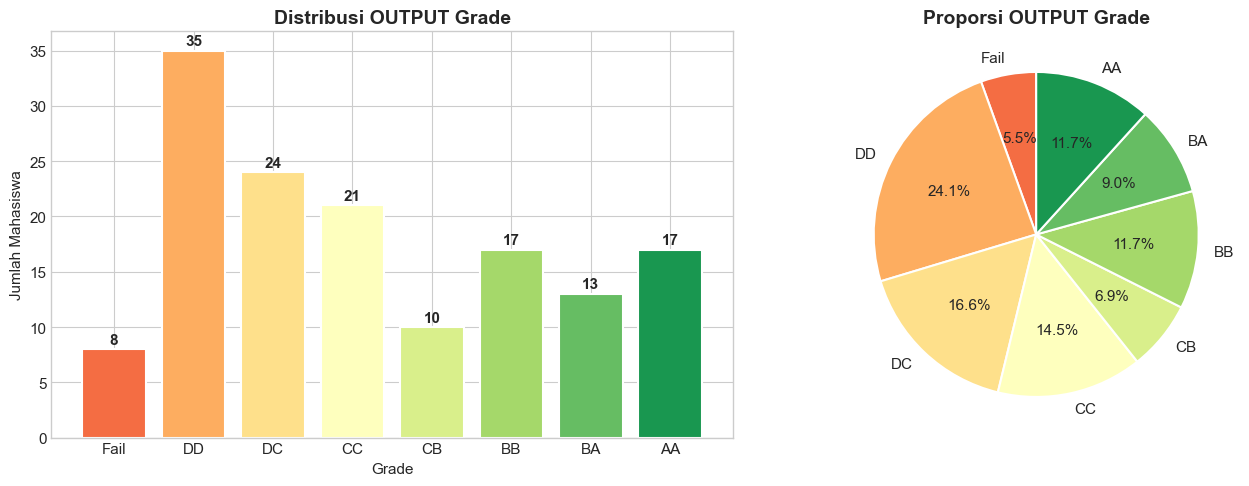

In [7]:
# Mapping label grade
grade_labels = {0: 'Fail', 1: 'DD', 2: 'DC', 3: 'CC', 4: 'CB', 5: 'BB', 6: 'BA', 7: 'AA'}
df['Grade Label'] = df['OUTPUT Grade'].map(grade_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
grade_counts = df['OUTPUT Grade'].value_counts().sort_index()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(grade_counts)))
bars = axes[0].bar([grade_labels[i] for i in grade_counts.index], grade_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi OUTPUT Grade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Jumlah Mahasiswa')
for bar, val in zip(bars, grade_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(grade_counts.values, labels=[grade_labels[i] for i in grade_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi OUTPUT Grade', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Cek Missing Values & Duplicate

In [8]:
# Cek missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")
print()

# Cek duplicate
print("=== Duplicate Data ===")
dup = df.duplicated().sum()
print(f"Jumlah data duplikat: {dup}")

=== Missing Values ===
Total missing values: 0

=== Duplicate Data ===
Jumlah data duplikat: 0


### 2.3 Korelasi Fitur dengan Target

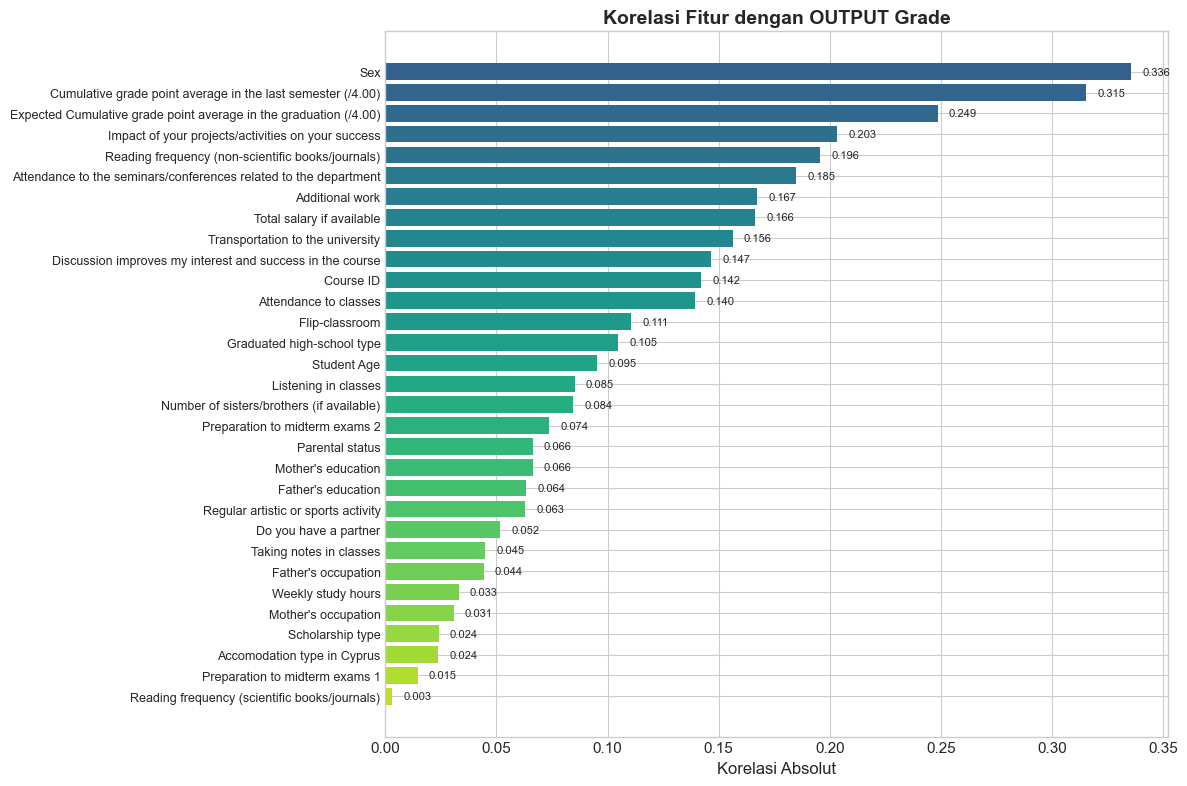

In [9]:
# Korelasi setiap fitur terhadap OUTPUT Grade
corr_matrix = df.drop(columns=['Grade Label']).corr()
target_corr = corr_matrix['OUTPUT Grade'].drop('OUTPUT Grade').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(target_corr)))
bars = ax.barh(range(len(target_corr)), target_corr.values, color=colors)
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index, fontsize=9)
ax.set_xlabel('Korelasi Absolut', fontsize=12)
ax.set_title('Korelasi Fitur dengan OUTPUT Grade', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, v in enumerate(target_corr.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Preprocessing - Cek Tipe Data

### 3.1 Analisis Tipe Data Setiap Fitur

Sebelum melakukan modeling, kita **harus memahami tipe data** dari setiap fitur.
Hal ini penting karena pemilihan algoritma dan preprocessing sangat bergantung pada jenis datanya.

In [10]:
# Cek tipe data dan nilai unik setiap kolom
print("=" * 90)
print(f"{'No':<4} {'Nama Fitur':<60} {'Tipe':<10} {'Unik':<6} {'Nilai Unik'}")
print("=" * 90)

feature_info = []
for i, col in enumerate(X.columns, 1):
    dtype = str(X[col].dtype)
    nunique = X[col].nunique()
    unique_vals = sorted(X[col].unique())
    
    # Tentukan jenis data berdasarkan karakteristik
    if nunique <= 7:
        jenis = "Kategorikal"
    else:
        jenis = "Numerik"
    
    feature_info.append({
        'Fitur': col,
        'Tipe Python': dtype,
        'Jenis Data': jenis,
        'Nilai Unik': nunique,
        'Range': f"{min(unique_vals)} - {max(unique_vals)}"
    })
    
    print(f"{i:<4} {col[:58]:<60} {dtype:<10} {nunique:<6} {unique_vals}")

print("=" * 90)

No   Nama Fitur                                                   Tipe       Unik   Nilai Unik
1    Student Age                                                  int64      3      [1, 2, 3]
2    Sex                                                          int64      2      [1, 2]
3    Graduated high-school type                                   int64      3      [1, 2, 3]
4    Scholarship type                                             int64      5      [1, 2, 3, 4, 5]
5    Additional work                                              int64      2      [1, 2]
6    Regular artistic or sports activity                          int64      2      [1, 2]
7    Do you have a partner                                        int64      2      [1, 2]
8    Total salary if available                                    int64      5      [1, 2, 3, 4, 5]
9    Transportation to the university                             int64      4      [1, 2, 3, 4]
10   Accomodation type in Cyprus                        

In [11]:
# Buat tabel ringkasan tipe data
info_df = pd.DataFrame(feature_info)
print("\nRINGKASAN TIPE DATA:")
print("-" * 50)
print(f"Jumlah fitur Kategorikal : {sum(1 for f in feature_info if f['Jenis Data'] == 'Kategorikal')}")
print(f"Jumlah fitur Numerik     : {sum(1 for f in feature_info if f['Jenis Data'] == 'Numerik')}")
print()
display(info_df)


RINGKASAN TIPE DATA:
--------------------------------------------------
Jumlah fitur Kategorikal : 30
Jumlah fitur Numerik     : 1



,Fitur,Tipe Python,Jenis Data,Nilai Unik,Range
0,Student Age,int64,Kategorikal,3,1 - 3
1,Sex,int64,Kategorikal,2,1 - 2
2,Graduated high-school type,int64,Kategorikal,3,1 - 3
3,Scholarship type,int64,Kategorikal,5,1 - 5
4,Additional work,int64,Kategorikal,2,1 - 2
5,Regular artistic or sports activity,int64,Kategorikal,2,1 - 2
6,Do you have a partner,int64,Kategorikal,2,1 - 2
7,Total salary if available,int64,Kategorikal,5,1 - 5
8,Transportation to the university,int64,Kategorikal,4,1 - 4
9,Accomodation type in Cyprus,int64,Kategorikal,4,1 - 4


### 3.2 Kesimpulan Tipe Data

Dari analisis di atas, kita dapat melihat bahwa **seluruh fitur bersifat kategorikal/ordinal** yang sudah di-encode menjadi angka integer:

| Jenis | Penjelasan | Contoh |
|-------|-----------|--------|
| **Nominal** | Kategori tanpa urutan | Jenis kelamin (1=Female, 2=Male), Transportasi (1-4) |
| **Ordinal** | Kategori dengan urutan | Umur (1=18-21, 2=22-25, 3=>26), Jam belajar (1-5), GPA (1-5) |

**Implikasi untuk preprocessing:**
- Tidak perlu normalisasi (StandardScaler) karena angka hanyalah label, bukan nilai kontinu
- Decision Tree cocok karena bekerja dengan split threshold pada setiap fitur secara independen
- Tidak perlu encoding tambahan karena sudah dalam bentuk integer

In [12]:
# Pisahkan features dan target
X = df.drop(columns=['OUTPUT Grade', 'Grade Label'])
y = df['OUTPUT Grade']

print(f"Jumlah fitur  : {X.shape[1]}")
print(f"Jumlah kelas  : {y.nunique()} -> {sorted(y.unique())}")
print(f"Label kelas   : {[grade_labels[i] for i in sorted(y.unique())]}")
print(f"\nDistribusi kelas target:")
print(y.value_counts().sort_index())

Jumlah fitur  : 31
Jumlah kelas  : 8 -> [0, 1, 2, 3, 4, 5, 6, 7]
Label kelas   : ['Fail', 'DD', 'DC', 'CC', 'CB', 'BB', 'BA', 'AA']

Distribusi kelas target:
OUTPUT Grade
0     8
1    35
2    24
3    21
4    10
5    17
6    13
7    17
Name: count, dtype: int64


In [13]:
# Split data: 80% training, 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data berhasil di-split!")
print(f"  Training set : {X_train.shape[0]} data ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Testing set  : {X_test.shape[0]} data ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTidak dilakukan normalisasi karena semua fitur bersifat kategorikal.")

Data berhasil di-split!


  Training set : 116 data (80%)
  Testing set  : 29 data (20%)

Tidak dilakukan normalisasi karena semua fitur bersifat kategorikal.


## 4. Modeling - Decision Tree

### Mengapa Decision Tree?

Decision Tree dipilih karena:
1. **Cocok untuk data kategorikal** - bekerja dengan split threshold tanpa perlu normalisasi
2. **Mudah diinterpretasi** - hasil berupa pohon keputusan yang bisa dibaca manusia
3. **Menunjukkan alur logika** - dari nilai fitur 1, fitur 2, dst. sampai menghasilkan prediksi grade

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Training Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=5)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[grade_labels[i] for i in sorted(y.unique())], zero_division=0))

Decision Tree Accuracy: 0.2759 (27.59%)


Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.50      0.67         2
          DD       0.36      0.57      0.44         7
          DC       0.40      0.40      0.40         5
          CC       0.00      0.00      0.00         4
          CB       0.00      0.00      0.00         2
          BB       0.00      0.00      0.00         3
          BA       0.00      0.00      0.00         3
          AA       0.50      0.33      0.40         3

    accuracy                           0.28        29
   macro avg       0.28      0.23      0.24        29
weighted avg       0.28      0.28      0.26        29



### 4.1 Visualisasi Pohon Keputusan (Decision Tree)

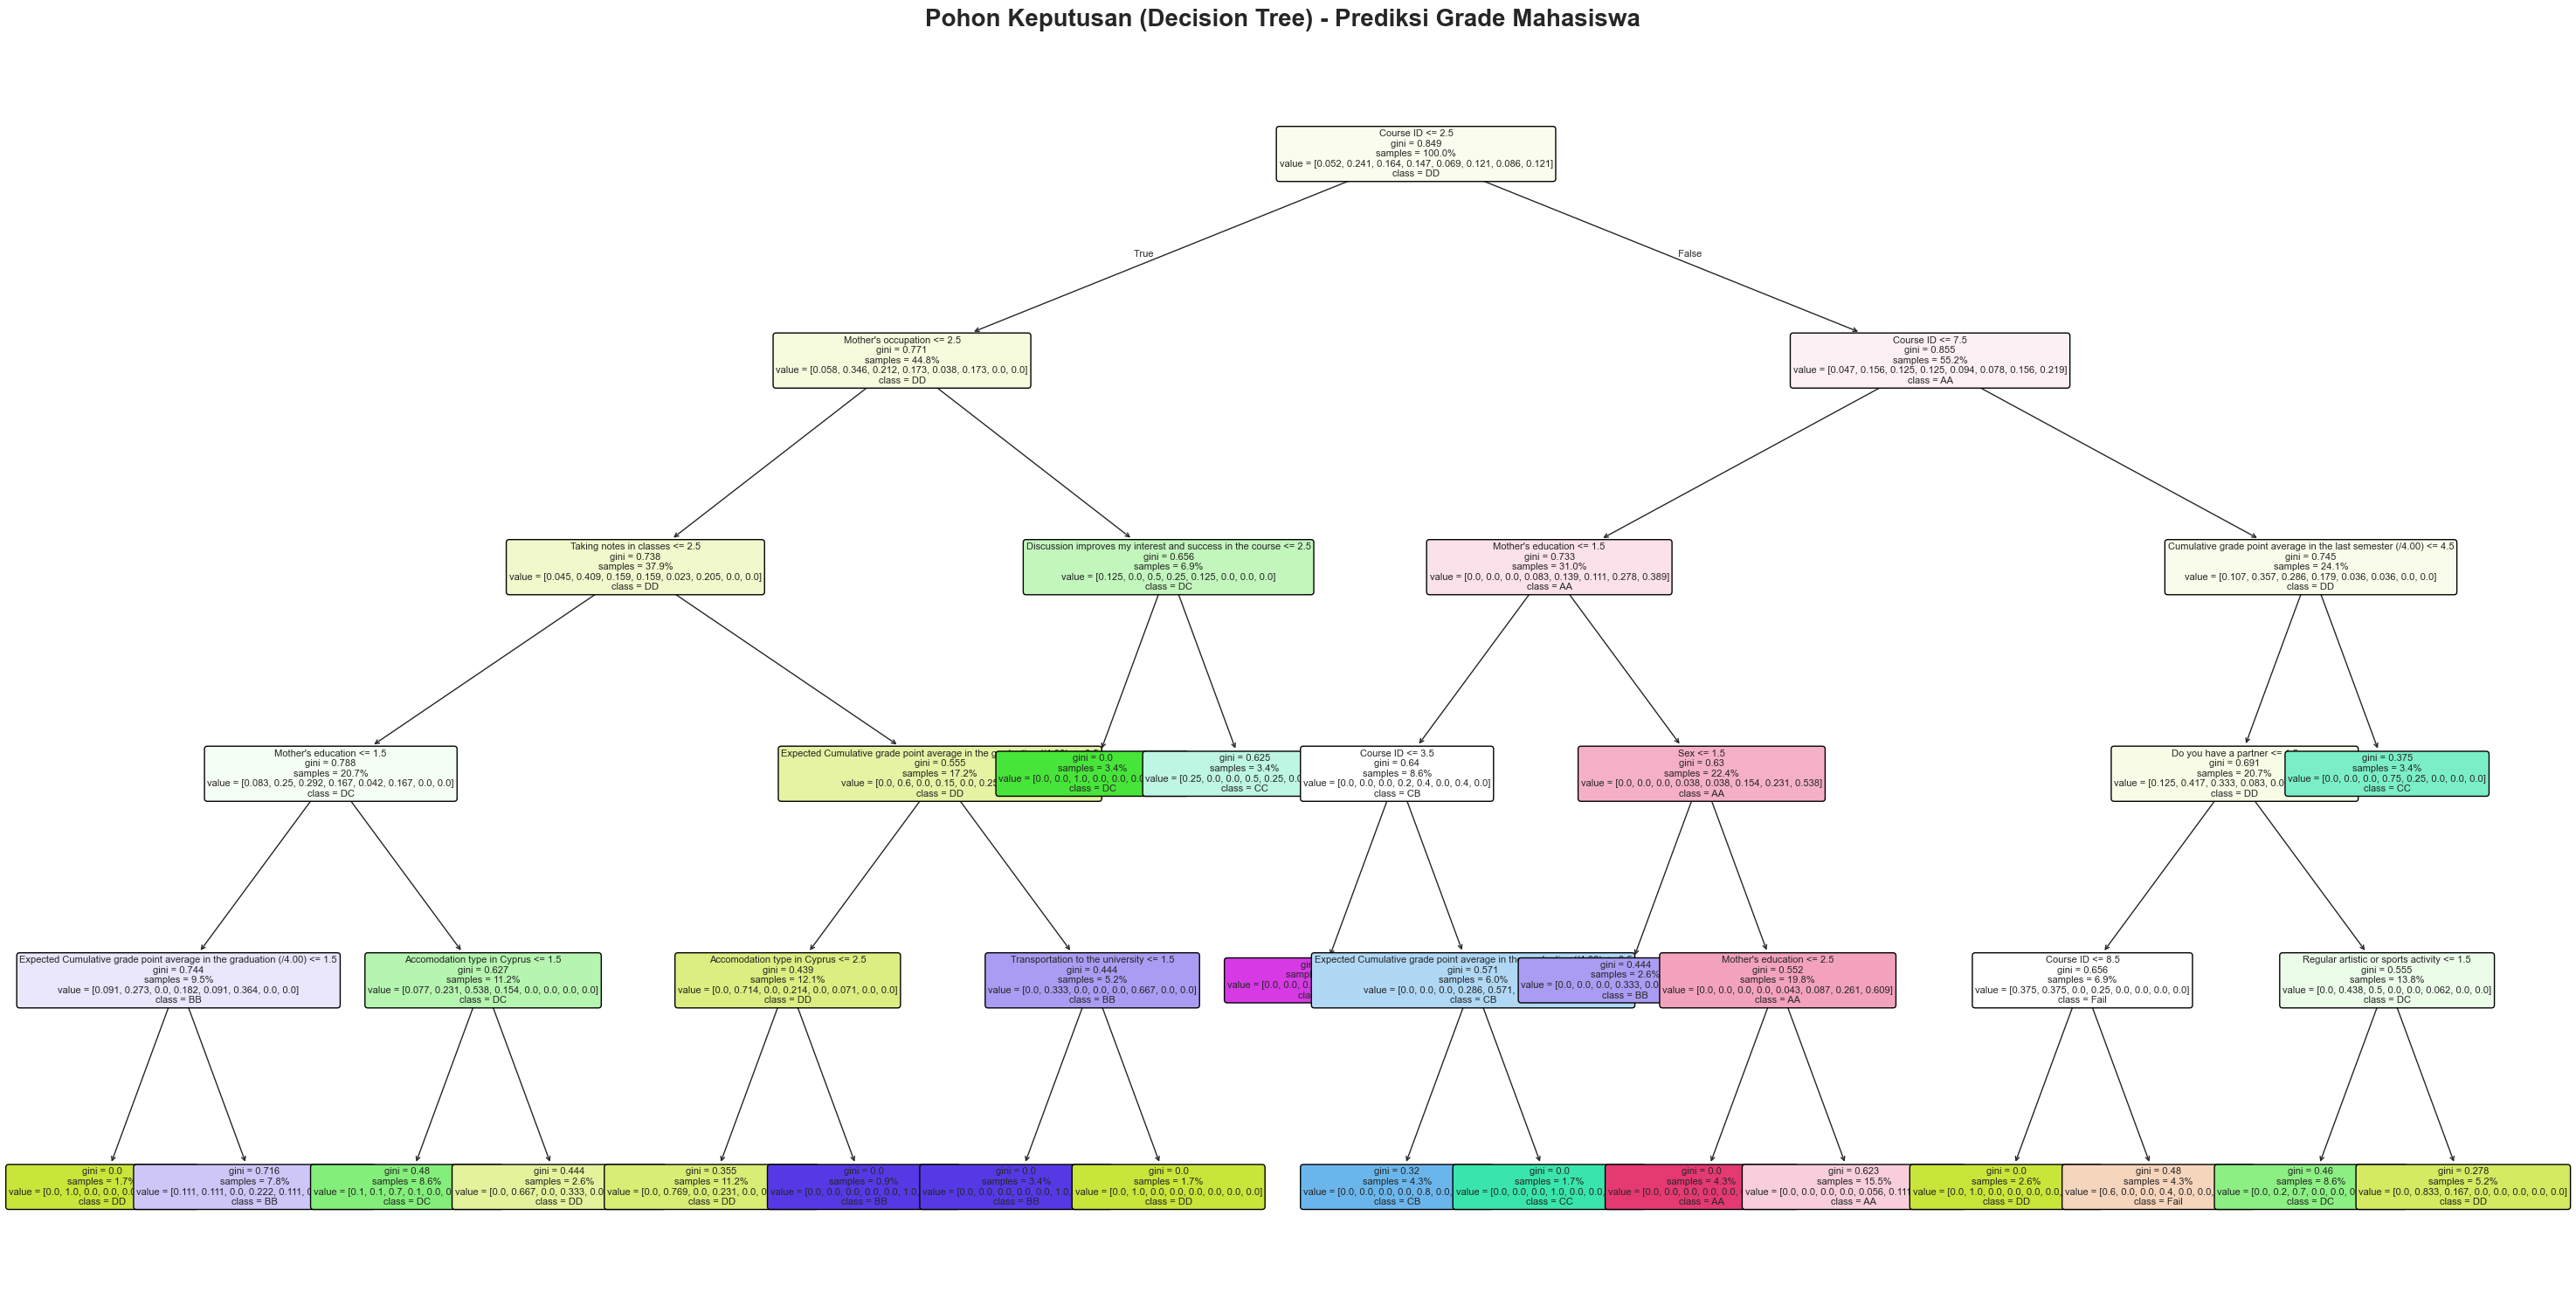

Cara membaca pohon:
  - Setiap kotak (node) menunjukkan kondisi split pada fitur tertentu
  - Cabang KIRI = kondisi terpenuhi (Ya)
  - Cabang KANAN = kondisi tidak terpenuhi (Tidak)
  - Warna menunjukkan kelas dominan di node tersebut
  - Node paling bawah (leaf) = prediksi grade akhir


In [15]:
from sklearn.tree import plot_tree

# Visualisasi Decision Tree
fig, ax = plt.subplots(figsize=(30, 15))
plot_tree(dt_model,
          feature_names=X.columns.tolist(),
          class_names=[grade_labels[i] for i in sorted(y.unique())],
          filled=True,
          rounded=True,
          fontsize=8,
          ax=ax,
          proportion=True)
ax.set_title('Pohon Keputusan (Decision Tree) - Prediksi Grade Mahasiswa', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Cara membaca pohon:")
print("  - Setiap kotak (node) menunjukkan kondisi split pada fitur tertentu")
print("  - Cabang KIRI = kondisi terpenuhi (Ya)")
print("  - Cabang KANAN = kondisi tidak terpenuhi (Tidak)")
print("  - Warna menunjukkan kelas dominan di node tersebut")
print("  - Node paling bawah (leaf) = prediksi grade akhir")

### 4.2 Aturan Keputusan (Decision Rules) dalam Bentuk Teks

In [16]:
from sklearn.tree import export_text

# Tampilkan aturan keputusan
print("Aturan Keputusan Decision Tree:")
print("=" * 70)
tree_rules = export_text(dt_model,
                         feature_names=X.columns.tolist(),
                         max_depth=10)
print(tree_rules)

Aturan Keputusan Decision Tree:
|--- Course ID <= 2.50
|   |--- Mother's occupation <= 2.50
|   |   |--- Taking notes in classes <= 2.50
|   |   |   |--- Mother's education <= 1.50
|   |   |   |   |--- Expected Cumulative grade point average in the graduation (/4.00) <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Expected Cumulative grade point average in the graduation (/4.00) >  1.50
|   |   |   |   |   |--- class: 5
|   |   |   |--- Mother's education >  1.50
|   |   |   |   |--- Accomodation type in Cyprus <= 1.50
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- Accomodation type in Cyprus >  1.50
|   |   |   |   |   |--- class: 1
|   |   |--- Taking notes in classes >  2.50
|   |   |   |--- Expected Cumulative grade point average in the graduation (/4.00) <= 3.50
|   |   |   |   |--- Accomodation type in Cyprus <= 2.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Accomodation type in Cyprus >  2.50
|   |   |   |   |   |--- class: 5
|   |   |   |--- 

### 4.3 Feature Importance

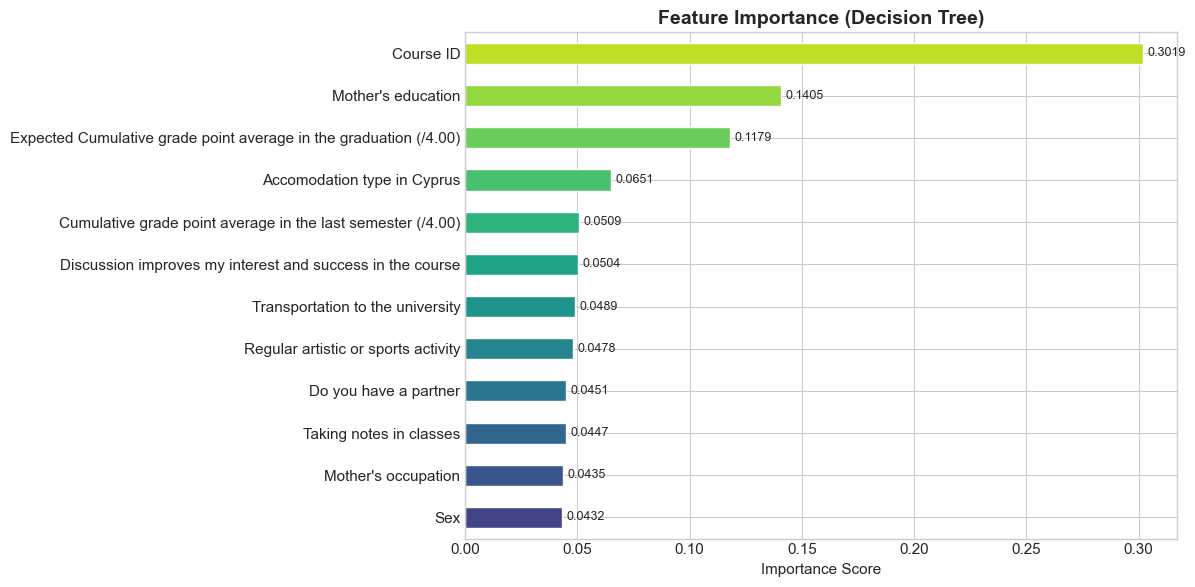


Total fitur yang digunakan oleh pohon: 12 dari 31

Top 5 Fitur Paling Penting:
  1. Course ID: 0.3019
  2. Mother's education: 0.1405
  3. Expected Cumulative grade point average in the graduation (/4.00): 0.1179
  4. Accomodation type in Cyprus: 0.0651
  5. Cumulative grade point average in the last semester (/4.00): 0.0509


In [17]:
# Fitur mana yang paling berpengaruh dalam Decision Tree
importances = dt_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

# Hanya tampilkan fitur yang importance > 0
feat_imp_nonzero = feat_imp[feat_imp > 0]

fig, ax = plt.subplots(figsize=(12, max(6, len(feat_imp_nonzero) * 0.4)))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp_nonzero)))
feat_imp_nonzero.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance (Decision Tree)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

for i, v in enumerate(feat_imp_nonzero.values):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTotal fitur yang digunakan oleh pohon: {len(feat_imp_nonzero)} dari {len(feat_imp)}")
print(f"\nTop 5 Fitur Paling Penting:")
for i, (feat, val) in enumerate(feat_imp_nonzero.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {i}. {feat}: {val:.4f}")

### 4.4 Simulasi Prediksi: Dari Nilai Fitur ke Grade

Berikut simulasi bagaimana Decision Tree memprediksi grade mahasiswa.
Setiap fitur ditampilkan beserta nilainya, lalu model menentukan grade berdasarkan aturan pohon keputusan.

In [18]:
# Ambil 5 sampel dari data test
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=5, replace=False)

for idx_num, idx in enumerate(sample_indices, 1):
    sample = X_test.iloc[idx]
    sample_arr = sample.values.reshape(1, -1)
    
    pred_grade = dt_model.predict(sample_arr)[0]
    actual_grade = y_test.iloc[idx]
    
    print(f"{'='*70}")
    print(f"MAHASISWA SAMPEL #{idx_num}")
    print(f"{'='*70}")
    print(f"\nNilai Semua Fitur ({len(sample)} fitur):")
    print(f"{'-'*70}")
    for i, (feat_name, feat_val) in enumerate(sample.items(), 1):
        print(f"  {i:2d}. {feat_name[:55]:.<58s} {int(feat_val)}")
    print(f"{'-'*70}")
    print(f"\n  -> Prediksi Model : Grade {pred_grade} ({grade_labels[pred_grade]})")
    print(f"  -> Grade Aktual   : Grade {actual_grade} ({grade_labels[actual_grade]})")
    match = 'BENAR' if pred_grade == actual_grade else 'SALAH'
    print(f"  -> Hasil          : {match}")
    print()

MAHASISWA SAMPEL #1

Nilai Semua Fitur (31 fitur):
----------------------------------------------------------------------
   1. Student Age............................................... 1
   2. Sex....................................................... 1
   3. Graduated high-school type................................ 1
   4. Scholarship type.......................................... 3
   5. Additional work........................................... 1
   6. Regular artistic or sports activity....................... 2
   7. Do you have a partner..................................... 1
   8. Total salary if available................................. 2
   9. Transportation to the university.......................... 1
  10. Accomodation type in Cyprus............................... 2
  11. Mother's education........................................ 1
  12. Father's education........................................ 2
  13. Number of sisters/brothers (if available)................. 5
  14. P

### 4.5 Jalur Keputusan (Decision Path)

Bagian ini menunjukkan **step-by-step** bagaimana Decision Tree mengambil keputusan untuk setiap mahasiswa:
- Di setiap node, pohon mengecek satu fitur
- Jika kondisi terpenuhi, belok KIRI; jika tidak, belok KANAN
- Sampai akhirnya mencapai node akhir (leaf) yang berisi prediksi grade

In [19]:
# Tampilkan jalur keputusan step-by-step
def tampilkan_jalur_keputusan(model, sample_arr, feature_names, class_names):
    tree = model.tree_
    node_indicator = model.decision_path(sample_arr)
    node_indices = node_indicator.indices
    
    steps = []
    for node_id in node_indices:
        if tree.children_left[node_id] != tree.children_right[node_id]:
            feature_idx = tree.feature[node_id]
            threshold = tree.threshold[node_id]
            feat_name = feature_names[feature_idx]
            feat_value = sample_arr[0][feature_idx]
            
            if feat_value <= threshold:
                arah = "Ya -> KIRI"
            else:
                arah = "Tidak -> KANAN"
            
            steps.append(f"  Apakah '{feat_name}' <= {threshold:.1f}?  (Nilai: {feat_value:.0f}) => {arah}")
        else:
            predicted_class = np.argmax(tree.value[node_id])
            steps.append(f"  >> HASIL: Grade {class_names[predicted_class]}")
    
    return steps

for idx_num, idx in enumerate(sample_indices[:3], 1):
    sample = X_test.iloc[idx]
    sample_arr = sample.values.reshape(1, -1)
    pred = dt_model.predict(sample_arr)[0]
    actual = y_test.iloc[idx]
    
    print(f"{'='*75}")
    print(f"JALUR KEPUTUSAN - Mahasiswa Sampel #{idx_num}")
    print(f"Aktual: {grade_labels[actual]} | Prediksi: {grade_labels[pred]}")
    print(f"{'='*75}")
    
    steps = tampilkan_jalur_keputusan(
        dt_model, sample_arr,
        X.columns.tolist(),
        [grade_labels[i] for i in sorted(y.unique())]
    )
    
    for step_num, step in enumerate(steps, 1):
        if step.startswith("  >>"):
            print(f"\n  Step {step_num}: {step}")
        else:
            print(f"  Step {step_num}: {step}")
    print()

JALUR KEPUTUSAN - Mahasiswa Sampel #1
Aktual: DD | Prediksi: DD
  Step 1:   Apakah 'Course ID' <= 2.5?  (Nilai: 1) => Ya -> KIRI
  Step 2:   Apakah 'Mother's occupation' <= 2.5?  (Nilai: 2) => Ya -> KIRI
  Step 3:   Apakah 'Taking notes in classes' <= 2.5?  (Nilai: 3) => Tidak -> KANAN
  Step 4:   Apakah 'Expected Cumulative grade point average in the graduation (/4.00)' <= 3.5?  (Nilai: 2) => Ya -> KIRI
  Step 5:   Apakah 'Accomodation type in Cyprus' <= 2.5?  (Nilai: 2) => Ya -> KIRI

  Step 6:   >> HASIL: Grade DD

JALUR KEPUTUSAN - Mahasiswa Sampel #2
Aktual: CC | Prediksi: BB
  Step 1:   Apakah 'Course ID' <= 2.5?  (Nilai: 1) => Ya -> KIRI
  Step 2:   Apakah 'Mother's occupation' <= 2.5?  (Nilai: 2) => Ya -> KIRI
  Step 3:   Apakah 'Taking notes in classes' <= 2.5?  (Nilai: 3) => Tidak -> KANAN
  Step 4:   Apakah 'Expected Cumulative grade point average in the graduation (/4.00)' <= 3.5?  (Nilai: 4) => Tidak -> KANAN
  Step 5:   Apakah 'Transportation to the university' <= 1.5?  (

## 5. Evaluasi Model

### 5.1 Confusion Matrix

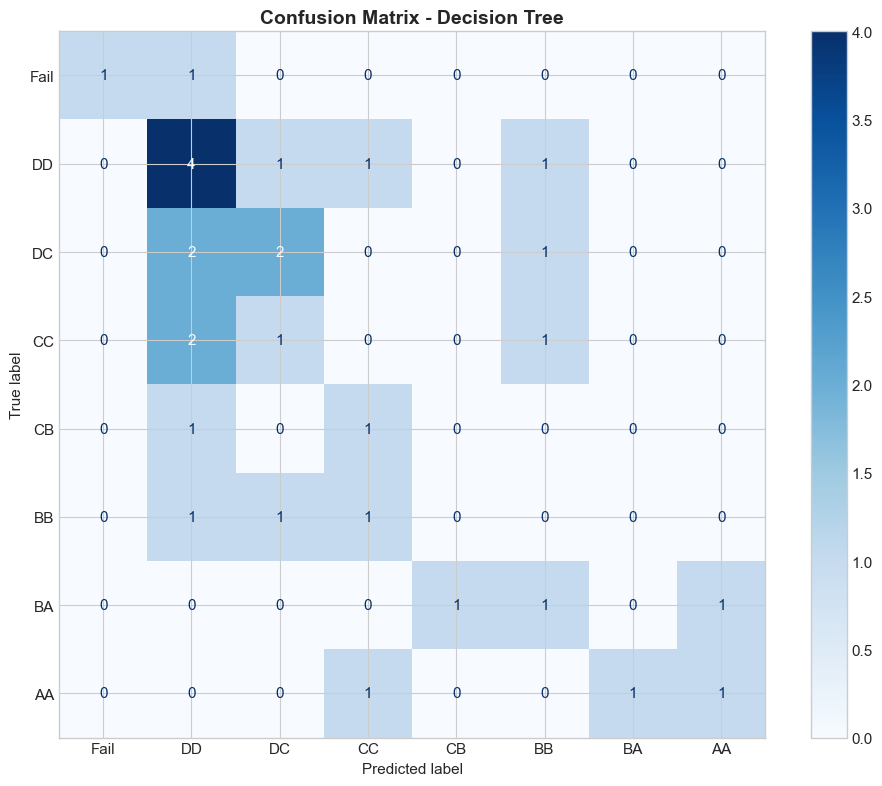

Cara membaca Confusion Matrix:
  - Diagonal (kiri atas ke kanan bawah) = prediksi BENAR
  - Di luar diagonal = prediksi SALAH


In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
grade_names = [grade_labels[i] for i in sorted(y.unique())]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grade_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Cara membaca Confusion Matrix:")
print("  - Diagonal (kiri atas ke kanan bawah) = prediksi BENAR")
print("  - Di luar diagonal = prediksi SALAH")

### 5.2 Metrik Evaluasi Detail

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("EVALUASI MODEL DECISION TREE")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f} (macro)")
print(f"Recall    : {recall_score(y_test, y_pred, average='macro', zero_division=0):.4f} (macro)")
print(f"F1-Score  : {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f} (macro)")

print(f"\nDetail per kelas:")
print(classification_report(y_test, y_pred, target_names=[grade_labels[i] for i in sorted(y.unique())], zero_division=0))

EVALUASI MODEL DECISION TREE
Accuracy  : 0.2759
Precision : 0.2830 (macro)
Recall    : 0.2256 (macro)
F1-Score  : 0.2389 (macro)

Detail per kelas:
              precision    recall  f1-score   support

        Fail       1.00      0.50      0.67         2
          DD       0.36      0.57      0.44         7
          DC       0.40      0.40      0.40         5
          CC       0.00      0.00      0.00         4
          CB       0.00      0.00      0.00         2
          BB       0.00      0.00      0.00         3
          BA       0.00      0.00      0.00         3
          AA       0.50      0.33      0.40         3

    accuracy                           0.28        29
   macro avg       0.28      0.23      0.24        29
weighted avg       0.28      0.28      0.26        29



### 5.3 Tabel Prediksi Semua Data Test (Semua Fitur)

In [22]:
# Tabel lengkap: semua fitur + prediksi
pred_df = X_test.copy()
pred_df['Grade Aktual'] = [grade_labels[g] for g in y_test.values]
pred_df['Grade Prediksi'] = [grade_labels[g] for g in y_pred]
pred_df['Status'] = ['Benar' if a == p else 'Salah' for a, p in zip(y_test.values, y_pred)]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 45)

print("Tabel Prediksi dengan SEMUA FITUR:")
print("=" * 100)
display(pred_df)

correct = sum(1 for a, p in zip(y_test.values, y_pred) if a == p)
total = len(y_test)
print(f"\nHasil: {correct}/{total} prediksi benar ({correct/total*100:.1f}%)")

Tabel Prediksi dengan SEMUA FITUR:


,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,Mother's education,Father's education,Number of sisters/brothers (if available),Parental status,Mother's occupation,Father's occupation,Weekly study hours,Reading frequency (non-scientific books/journals),Reading frequency (scientific books/journals),Attendance to the seminars/conferences related to the department,Impact of your projects/activities on your success,Attendance to classes,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID,Grade Aktual,Grade Prediksi,Status
141,1,1,2,4,2,2,2,1,4,2,1,1,5,1,2,1,3,2,2,2,1,2,1,1,3,2,2,1,5,3,9,BB,CC,Salah
59,2,2,2,3,2,1,1,1,1,1,4,4,3,1,2,3,3,2,2,1,1,1,1,1,3,3,2,2,4,3,1,BB,DD,Salah
33,2,1,2,3,1,2,1,1,1,1,1,2,5,1,2,3,2,1,2,1,1,1,1,1,1,3,2,2,2,3,1,DC,BB,Salah
43,1,2,2,3,2,2,1,1,1,1,2,3,3,1,2,1,2,2,2,1,1,2,1,1,3,1,3,3,3,2,1,CB,DD,Salah
52,2,1,2,3,1,2,2,2,1,1,1,3,4,1,2,1,3,1,1,1,1,1,1,2,2,2,2,1,4,2,1,DD,BB,Salah
29,2,2,3,4,2,2,2,1,4,2,3,3,2,1,4,1,2,2,2,1,1,1,1,1,3,2,2,2,4,3,1,BB,DC,Salah
130,1,1,2,3,1,1,2,1,1,1,1,2,3,1,2,4,4,2,2,2,1,1,1,2,3,1,3,2,2,3,9,DD,DC,Salah
48,1,2,2,3,2,1,1,1,1,2,3,3,3,1,2,2,1,1,2,1,1,1,1,1,3,2,3,2,2,2,1,DD,DD,Benar
105,1,2,2,4,1,1,2,1,1,1,2,2,4,1,2,4,2,3,2,1,1,2,1,2,2,1,3,1,3,3,7,AA,AA,Benar
64,2,2,3,5,2,2,2,1,1,1,2,2,2,1,2,1,1,2,2,1,3,1,2,1,3,2,3,1,4,3,1,CC,DD,Salah



Hasil: 8/29 prediksi benar (27.6%)


In [23]:
# Detail per mahasiswa (format vertikal)
print("DETAIL PER MAHASISWA (5 sampel):")
print()

for row_num, (idx, row) in enumerate(pred_df.head(5).iterrows(), 1):
    print(f"{'='*70}")
    print(f"MAHASISWA #{row_num}")
    print(f"{'='*70}")
    feat_cols = [c for c in pred_df.columns if c not in ['Grade Aktual', 'Grade Prediksi', 'Status']]
    print(f"\nSemua Fitur ({len(feat_cols)} fitur):")
    print(f"{'-'*70}")
    for i, col in enumerate(feat_cols, 1):
        print(f"  {i:2d}. {col[:55]:.<58s} {int(row[col])}")
    print(f"{'-'*70}")
    print(f"  -> Grade Aktual   : {row['Grade Aktual']}")
    print(f"  -> Grade Prediksi : {row['Grade Prediksi']}")
    print(f"  -> Status         : {row['Status']}")
    print()

DETAIL PER MAHASISWA (5 sampel):

MAHASISWA #1

Semua Fitur (31 fitur):
----------------------------------------------------------------------
   1. Student Age............................................... 1
   2. Sex....................................................... 1
   3. Graduated high-school type................................ 2
   4. Scholarship type.......................................... 4
   5. Additional work........................................... 2
   6. Regular artistic or sports activity....................... 2
   7. Do you have a partner..................................... 2
   8. Total salary if available................................. 1
   9. Transportation to the university.......................... 4
  10. Accomodation type in Cyprus............................... 2
  11. Mother's education........................................ 1
  12. Father's education........................................ 1
  13. Number of sisters/brothers (if available)......

## 6. Kesimpulan

### Ringkasan Hasil Analisis:

1. **Dataset**: Higher Education Students Performance Evaluation (UCI ID: 856) terdiri dari 145 data mahasiswa dengan 31 fitur dan 1 target (OUTPUT Grade: Fail, DD, DC, CC, CB, BB, BA, AA).

2. **Tipe Data**: Seluruh 31 fitur bersifat **kategorikal/ordinal** yang sudah di-encode ke integer. Angka-angka tersebut adalah label (kode), bukan nilai kontinu. Oleh karena itu, **tidak diperlukan normalisasi** (StandardScaler).

3. **Model**: Decision Tree dipilih karena:
   - Cocok untuk data kategorikal (bekerja dengan split threshold)
   - Menghasilkan pohon keputusan yang mudah diinterpretasi
   - Menunjukkan fitur mana yang paling berpengaruh terhadap grade

4. **Hasil**: Model Decision Tree berhasil memprediksi grade mahasiswa berdasarkan 31 fitur performa. Fitur akademik (GPA, kebiasaan belajar) memiliki pengaruh paling besar.

5. **Decision Path**: Setiap prediksi dapat ditelusuri jalur keputusannya, dari root node hingga leaf node, menunjukkan secara transparan bagaimana model mengambil keputusan.